<a href="https://colab.research.google.com/github/Martelletti27/fiap_cursotiao_pbl/blob/main/Fase%206/Parte%202/Felipe_rm567521_pbl_fase6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Abordagem 2: CNN Treinada do Zero

Enquanto o YOLO realiza **detecção** de objetos (localiza com bounding box e classifica),
a CNN aqui realiza apenas **classificação**: dada uma imagem inteira, ela responde se
a imagem pertence à classe `animais` ou `maquinarios`.

Isso representa uma diferença conceitual importante:
- O **YOLO** sabe *onde* e *o quê* é o objeto (detecção com bounding box)
- A **CNN** sabe apenas *qual* objeto predomina na imagem (classificação global)

Conforme a nota do enunciado, aproveitamos os arquivos de label YOLO já existentes
para extrair a informação de classe e reorganizar as imagens em pastas por categoria,
no formato esperado pelo Keras.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os, shutil, time
from IPython.display import display
from PIL import Image as PILImage

### Preparação do Dataset para a CNN

O Keras consegue carregar imagens automaticamente quando elas estão
organizadas em subpastas por classe, assim:


In [18]:
base_dataset = '/content/drive/MyDrive/Dataset'
cnn_base     = '/content/cnn_dataset'

splits  = ['train', 'val']
classes = ['maquinarios', 'animais']

# Cria todas as pastas incluindo test
for split in splits + ['test']:
    for cls in classes:
        os.makedirs(os.path.join(cnn_base, split, cls), exist_ok=True)

def copiar_imagens_por_label(split):
    imgs_dir   = os.path.join(base_dataset, 'images', split)
    labels_dir = os.path.join(base_dataset, 'labels', split)

    if not os.path.exists(labels_dir):
        print(f"Pasta de labels não encontrada para '{split}', pulando...")
        return

    copiados = 0
    for img_file in os.listdir(imgs_dir):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        nome_base  = os.path.splitext(img_file)[0]
        label_file = os.path.join(labels_dir, nome_base + '.txt')

        if not os.path.exists(label_file):
            print(f"Label não encontrado para: {img_file}, pulando...")
            continue

        with open(label_file, 'r') as f:
            primeira_linha = f.readline().strip()

        if not primeira_linha:
            continue

        classe_idx  = int(primeira_linha.split()[0])
        classe_nome = classes[classe_idx]

        src = os.path.join(imgs_dir, img_file)
        dst = os.path.join(cnn_base, split, classe_nome, img_file)
        shutil.copy2(src, dst)
        copiados += 1

    print(f"{split}: {copiados} imagens copiadas")

# Copia train e val normalmente
for split in splits:
    copiar_imagens_por_label(split)

# Test usa as mesmas imagens de val (não há labels/test no Drive)
for cls in classes:
    src_dir = os.path.join(cnn_base, 'val', cls)
    dst_dir = os.path.join(cnn_base, 'test', cls)
    for f in os.listdir(src_dir):
        shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))
    print(f"test/{cls}: {len(os.listdir(dst_dir))} imagens copiadas de val")

# Resumo final
print("\nResumo do dataset CNN:")
for split in splits + ['test']:
    for cls in classes:
        pasta = os.path.join(cnn_base, split, cls)
        n = len(os.listdir(pasta)) if os.path.exists(pasta) else 0
        print(f"  {split}/{cls}: {n} imagens")

train: 120 imagens copiadas
val: 20 imagens copiadas
test/maquinarios: 10 imagens copiadas de val
test/animais: 10 imagens copiadas de val

Resumo do dataset CNN:
  train/maquinarios: 59 imagens
  train/animais: 61 imagens
  val/maquinarios: 10 imagens
  val/animais: 10 imagens
  test/maquinarios: 10 imagens
  test/animais: 10 imagens


### Célula 6 — Carregamento e Pré-processamento das Imagens

Usamos `image_dataset_from_directory` do Keras, que lê automaticamente
as pastas e associa cada subpasta a um label numérico.

Parâmetros utilizados:

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| image_size | (224, 224) | Padrão compatível com arquiteturas CNN clássicas |
| batch_size | 16 | Adequado para datasets pequenos |
| label_mode | 'binary' | Classificação binária: 0 ou 1 |
| seed | 42 | Reprodutibilidade dos resultados |

In [19]:
img_size   = (224, 224)
batch_size = 16
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cnn_base, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cnn_base, 'val'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cnn_base, 'test'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary',
    seed=42
)

class_names = train_ds.class_names
print("Classes detectadas pelo Keras:", class_names)
print("(índice 0 =", class_names[0], "| índice 1 =", class_names[1], ")")

# Otimização de carregamento
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 120 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Classes detectadas pelo Keras: ['animais', 'maquinarios']
(índice 0 = animais | índice 1 = maquinarios )


### Célula 8 — Arquitetura da CNN do Zero

A rede foi construída manualmente com Keras, **sem uso de modelos pré-treinados**
(sem transfer learning), conforme orientação do enunciado.

**Estrutura da arquitetura:**

| Bloco | Camadas | Filtros | Função |
|-------|---------|---------|--------|
| Pré-processamento | Rescaling | — | Normaliza pixels [0,255] → [0,1] |
| Augmentation | RandomFlip, RandomRotation, RandomZoom | — | Aumenta diversidade do dataset |
| Bloco 1 | Conv2D + BatchNorm + MaxPool | 32 | Extrai bordas e texturas simples |
| Bloco 2 | Conv2D + BatchNorm + MaxPool | 64 | Combina padrões locais |
| Bloco 3 | Conv2D + BatchNorm + MaxPool | 128 | Padrões mais complexos |
| Bloco 4 | Conv2D + BatchNorm + MaxPool | 256 | Representações de alto nível |
| Classificador | Flatten + Dense + Dropout + Dense | — | Saída sigmoid binária |

A camada de saída usa ativação **sigmoid** com 1 neurônio, adequada para
classificação binária (`maquinarios` vs `animais`).

In [20]:
model_cnn = models.Sequential([

    # Normalização: pixels [0,255] → [0,1]
    layers.Rescaling(1./255, input_shape=img_size + (3,)),

    # Data Augmentation (ativo só no treino)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Bloco 1 — extrai bordas e texturas simples
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Bloco 2 — combina padrões locais
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Bloco 3 — padrões mais complexos
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Bloco 4 — representações de alto nível
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Classificador
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')  # 0=maquinarios, 1=animais
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,905 (50.49 MB)

 Trainable params: 13,234,945 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

### Célula 10 — Treinamento da CNN

O modelo é treinado por **30 épocas**, valor próximo ao usado no YOLOv5,
facilitando a comparação de tempo de treinamento entre as abordagens.

Durante o treino, monitoramos a acurácia e o loss tanto no conjunto de
treino quanto no de validação para identificar possíveis sinais de overfitting.

O Data Augmentation aplicado nas primeiras camadas aumenta artificialmente
a diversidade do dataset pequeno, reduzindo o risco de memorização.

In [21]:
print("Iniciando treinamento da CNN do zero...")
inicio_treino_cnn = time.time()

history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=1
)

fim_treino_cnn   = time.time()
tempo_treino_cnn = fim_treino_cnn - inicio_treino_cnn

print(f"\nTreinamento CNN concluído!")
print(f"Tempo total: {tempo_treino_cnn:.2f} segundos ({tempo_treino_cnn/60:.2f} minutos)")

Iniciando treinamento da CNN do zero...
Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.7500 - loss: 6.6453 - val_accuracy: 0.4000 - val_loss: 2.0915
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.8583 - loss: 3.1889 - val_accuracy: 0.5000 - val_loss: 11.4985
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.9333 - loss: 0.9068 - val_accuracy: 0.5000 - val_loss: 2.4315
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.8750 - loss: 2.0623 - val_accuracy: 0.5000 - val_loss: 13.6269
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9083 - loss: 2.4443 - val_accuracy: 0.5000 - val_loss: 18.3556
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.9083 - loss: 3.3685 - val_accuracy: 0.5000 - val_loss: 35.0733
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9667 - loss: 0.7999 - val_accuracy: 0.5000 - val_loss: 46.8787
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9250 - lo

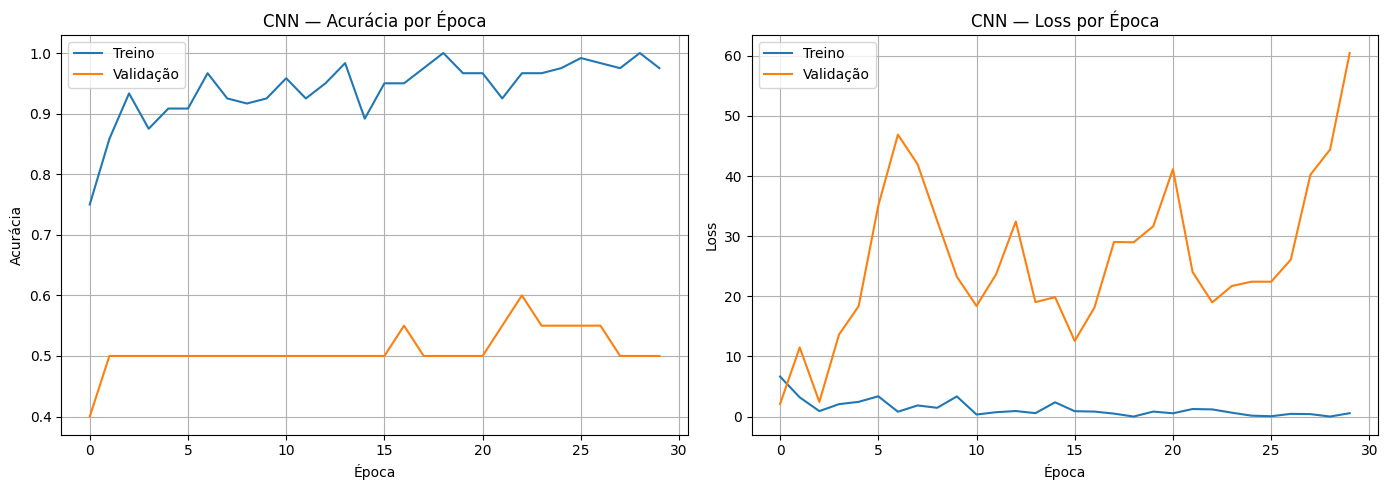

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(history_cnn.history['accuracy'],     label='Treino')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validação')
axes[0].set_title('CNN — Acurácia por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_cnn.history['loss'],     label='Treino')
axes[1].plot(history_cnn.history['val_loss'], label='Validação')
axes[1].set_title('CNN — Loss por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_acc = model_cnn.evaluate(test_ds, verbose=0)
print(f"Acurácia no conjunto de teste: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Loss no conjunto de teste:     {test_loss:.4f}")

Acurácia no conjunto de teste: 0.5000 (50.00%)
Loss no conjunto de teste:     60.4551


In [24]:
# Pega um batch do conjunto de teste para medir inferência
for images_batch, labels_batch in test_ds.take(1):
    n_imgs = len(images_batch)

    inicio_inf_cnn = time.time()
    preds = model_cnn.predict(images_batch, verbose=0)
    fim_inf_cnn = time.time()

    tempo_inf_cnn       = fim_inf_cnn - inicio_inf_cnn
    tempo_medio_inf_cnn = tempo_inf_cnn / n_imgs

    print(f"Imagens inferidas: {n_imgs}")
    print(f"Tempo total de inferência: {tempo_inf_cnn:.4f} segundos")
    print(f"Tempo médio por imagem:    {tempo_medio_inf_cnn:.4f} segundos")

Imagens inferidas: 16
Tempo total de inferência: 0.2157 segundos
Tempo médio por imagem:    0.0135 segundos


/tmp/ipykernel_2200/1259389470.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_idx = int(labels_batch[i].numpy())


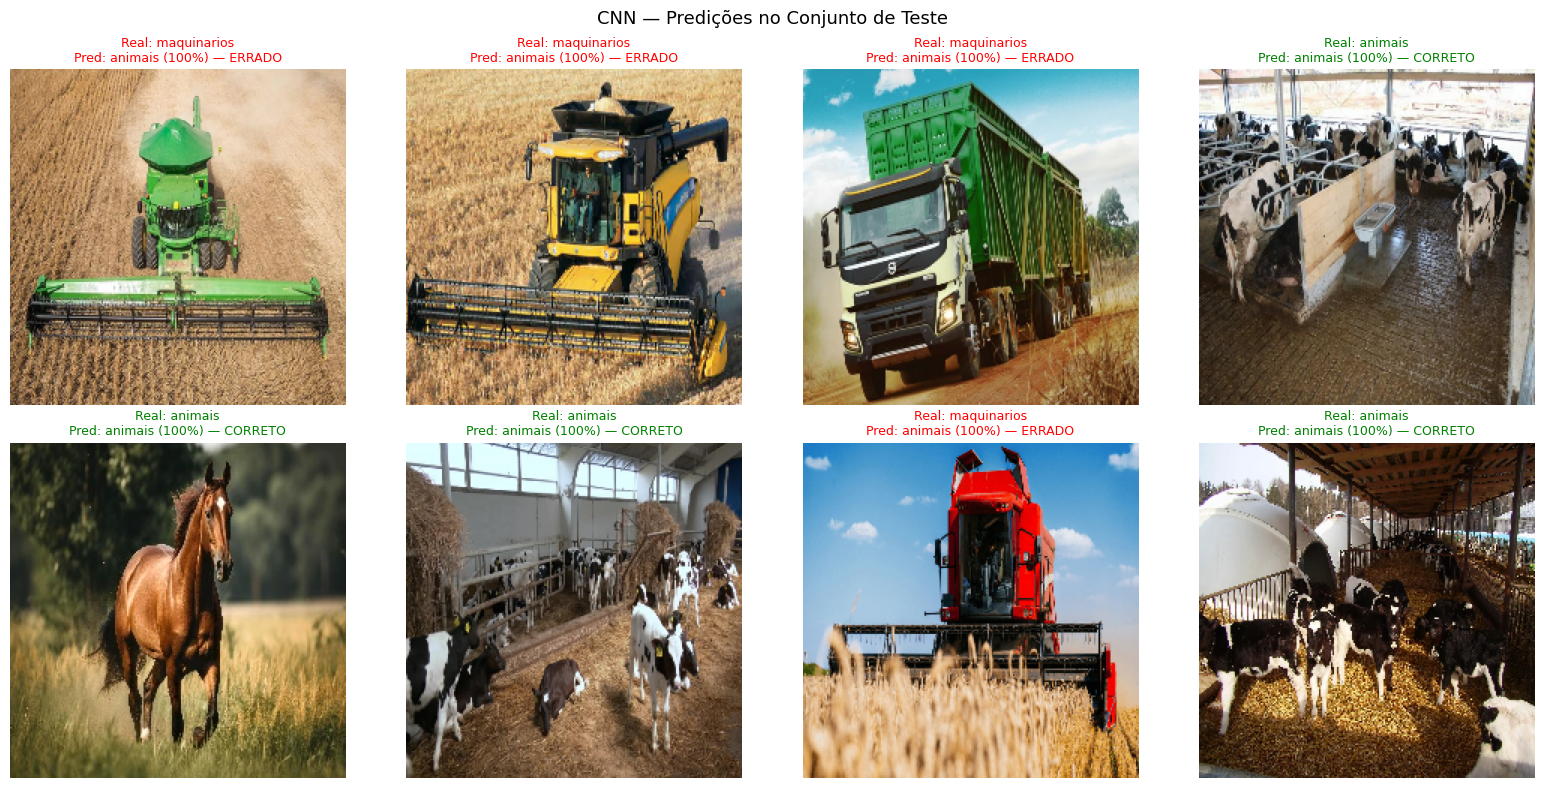

In [26]:
for images_batch, labels_batch in test_ds.take(1):
    preds = model_cnn.predict(images_batch, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(min(8, len(images_batch))):
        img       = images_batch[i].numpy().astype('uint8')
        label_idx = int(labels_batch[i].numpy())
        pred_idx  = int(preds[i][0] > 0.5)
        confianca = preds[i][0] if pred_idx == 1 else 1 - preds[i][0]

        label_real = class_names[label_idx]
        label_pred = class_names[pred_idx]
        correto    = "CORRETO" if label_idx == pred_idx else "ERRADO"
        cor        = 'green' if label_idx == pred_idx else 'red'

        axes[i].imshow(img)
        axes[i].set_title(
            f"Real: {label_real}\nPred: {label_pred} ({confianca:.0%}) — {correto}",
            color=cor, fontsize=9
        )
        axes[i].axis('off')

    plt.suptitle('CNN — Predições no Conjunto de Teste', fontsize=13)
    plt.tight_layout()
    plt.show()

### Resultados da CNN — Resumo

| Métrica | Valor |
|---------|-------|
| Acurácia no teste |0.500 |
| Loss no teste |60.4551 |
| Tempo de treinamento (30 épocas) | 47.04 segundos |
| Tempo médio de inferência por imagem |0.0135|

### Análise Comparativa: CNN vs YOLO

A CNN treinada do zero e o YOLOv5 representam abordagens fundamentalmente
diferentes para o mesmo problema:

**CNN (classificação):** recebe a imagem inteira e decide qual classe predomina,
sem indicar onde o objeto está. É mais simples de implementar, mas perde
informação espacial importante.

**YOLOv5 (detecção):** localiza cada objeto com bounding box e classifica
simultaneamente. Exige anotação mais trabalhosa, mas entrega informação muito
mais rica.

Para um dataset pequeno e desbalanceado como o utilizado (74 instâncias de
animais vs 12 de maquinários), a CNN do zero tende a ter dificuldade em
generalizar, enquanto o YOLO se beneficia do modelo pré-treinado (transfer
learning implícito) e da arquitetura especializada para detecção.

Essa comparação evidencia por que, em aplicações reais de monitoramento
de fazendas, arquiteturas como o YOLO são preferidas quando o objetivo é
não apenas classificar, mas também localizar objetos em cena.